In [7]:
import os
import matplotlib.pyplot as plt

In [8]:
# Check number of images per emotion
train_path = "archive/train"
for emotion in os.listdir(train_path):
    emotion_path = os.path.join(train_path, emotion)
    print(f"{emotion}: {len(os.listdir(emotion_path))} images")

angry: 3995 images
disgust: 436 images
fear: 4097 images
happy: 7215 images
neutral: 4965 images
sad: 4830 images
surprise: 3171 images


In [9]:
# Heavily augment the minority classes (especially disgust)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [6]:
# Check number of images per emotion
train_path = "archive/train"
for emotion in os.listdir(train_path):
    emotion_path = os.path.join(train_path, emotion)
    print(f"{emotion}: {len(os.listdir(emotion_path))} images")

angry: 3995 images
disgust: 436 images
fear: 4097 images
happy: 7215 images
neutral: 4965 images
sad: 4830 images
surprise: 3171 images


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Define paths
train_dir = 'archive/train'
test_dir = 'archive/test'
img_size = (48, 48)  # FER2013 uses 48x48, adjust if needed
batch_size = 32

# Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    rotation_range=20,       # Random rotation
    width_shift_range=0.2,   # Random horizontal shift
    height_shift_range=0.2,  # Random vertical shift
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Random horizontal flip
    fill_mode='nearest',     # Fill in missing pixels
    validation_split=0.2     # Use 20% for validation
)

# Only rescaling for Test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    color_mode='grayscale',  # FER2013 is grayscale
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False  # Important for evaluation
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels from training generator
class_labels = train_generator.classes
class_names = list(train_generator.class_indices.keys())

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

# Convert to dictionary format for Keras
class_weights_dict = dict(enumerate(class_weights))

print("Class distribution and weights:")
for i, class_name in enumerate(class_names):
    count = np.sum(class_labels == i)
    print(f"{class_name}: {count} samples, weight: {class_weights_dict[i]:.2f}")

Class distribution and weights:
angry: 3196 samples, weight: 1.03
disgust: 349 samples, weight: 9.40
fear: 3278 samples, weight: 1.00
happy: 5772 samples, weight: 0.57
neutral: 3972 samples, weight: 0.83
sad: 3864 samples, weight: 0.85
surprise: 2537 samples, weight: 1.29


Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Training samples: 22968
Validation samples: 5741


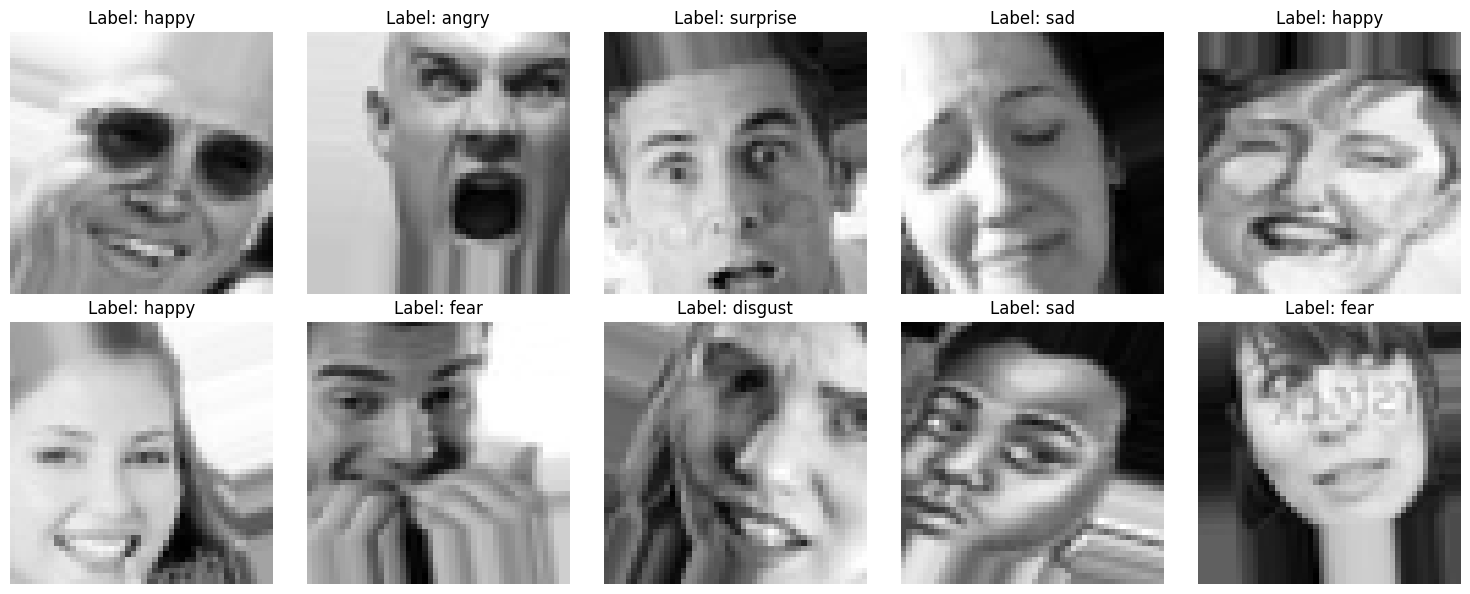

In [15]:
# Check if data is loading correctly
print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)

# Visualize some augmented images
import matplotlib.pyplot as plt

def plot_sample_images(generator):
    images, labels = next(generator)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f"Label: {class_names[np.argmax(labels[i])]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images(train_generator)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def create_model(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential()
    
    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    # Fourth Convolutional Block
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

# Create model
model = create_model()
model.summary()

C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,491,879 (9.51 MB)

 Trainable params: 2,488,423 (9.49 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [17]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks for better training
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_emotion_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
epochs = 50

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    class_weight=class_weights_dict,  # Use the class weights we calculated
    callbacks=callbacks,
    verbose=1
)

C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.1525 - loss: 2.6590
Epoch 1: val_accuracy improved from None to 0.20449, saving model to best_emotion_model.h5


718/718 ━━━━━━━━━━━━━━━━━━━━ 519s 711ms/step - accuracy: 0.1533 - loss: 2.3911 - val_accuracy: 0.2045 - val_loss: 1.8720 - learning_rate: 0.0010
Epoch 2/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.1627 - loss: 2.0686
Epoch 2: val_accuracy did not improve from 0.20449
718/718 ━━━━━━━━━━━━━━━━━━━━ 313s 436ms/step - accuracy: 0.1583 - loss: 2.0348 - val_accuracy: 0.0902 - val_loss: 2.0358 - learning_rate: 0.0010
Epoch 3/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.1606 - loss: 1.9906
Epoch 3: val_accuracy did not improve from 0.20449
718/718 ━━━━━━━━━━━━━━━━━━━━ 291s 405ms/step - accuracy: 0.1621 - loss: 1.9611 - val_accuracy: 0.1864 - val_loss: 1.9198 - learning_rate: 0.0010
Epoch 4/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.1792 - loss: 1.9454
Epoch 4: val_accuracy did not improve from 0.20449
718/718 ━━━━━━━━━━━━━━━━━━━━ 290s 404ms/step - accuracy: 0.1807 - loss: 1.9234 - val_accuracy: 0.1383 - val_loss: 1.9496 - learning_rate: 0.0010
Epo

718/718 ━━━━━━━━━━━━━━━━━━━━ 292s 407ms/step - accuracy: 0.2104 - loss: 1.8599 - val_accuracy: 0.2761 - val_loss: 1.7749 - learning_rate: 0.0010
Epoch 6/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.2345 - loss: 1.8242
Epoch 6: val_accuracy did not improve from 0.27608
718/718 ━━━━━━━━━━━━━━━━━━━━ 290s 404ms/step - accuracy: 0.2408 - loss: 1.8243 - val_accuracy: 0.2252 - val_loss: 1.8304 - learning_rate: 0.0010
Epoch 7/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.2643 - loss: 1.7925
Epoch 7: val_accuracy did not improve from 0.27608
718/718 ━━━━━━━━━━━━━━━━━━━━ 291s 405ms/step - accuracy: 0.2720 - loss: 1.8003 - val_accuracy: 0.1878 - val_loss: 1.9505 - learning_rate: 0.0010
Epoch 8/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.2761 - loss: 1.7940
Epoch 8: val_accuracy improved from 0.27608 to 0.32242, saving model to best_emotion_model.h5


718/718 ━━━━━━━━━━━━━━━━━━━━ 293s 407ms/step - accuracy: 0.2899 - loss: 1.7656 - val_accuracy: 0.3224 - val_loss: 1.7095 - learning_rate: 0.0010
Epoch 9/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.3285 - loss: 1.7239
Epoch 9: val_accuracy improved from 0.32242 to 0.33217, saving model to best_emotion_model.h5


...

718/718 ━━━━━━━━━━━━━━━━━━━━ 293s 408ms/step - accuracy: 0.5603 - loss: 1.1252 - val_accuracy: 0.5827 - val_loss: 1.1217 - learning_rate: 5.0000e-04
Epoch 40/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5694 - loss: 1.1095
Epoch 40: val_accuracy improved from 0.58265 to 0.58561, saving model to best_emotion_model.h5


718/718 ━━━━━━━━━━━━━━━━━━━━ 290s 404ms/step - accuracy: 0.5694 - loss: 1.0990 - val_accuracy: 0.5856 - val_loss: 1.0942 - learning_rate: 5.0000e-04
Epoch 41/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5803 - loss: 1.0847
Epoch 41: val_accuracy did not improve from 0.58561
718/718 ━━━━━━━━━━━━━━━━━━━━ 290s 404ms/step - accuracy: 0.5751 - loss: 1.0903 - val_accuracy: 0.5624 - val_loss: 1.1452 - learning_rate: 5.0000e-04
Epoch 42/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.5745 - loss: 1.0781
Epoch 42: val_accuracy did not improve from 0.58561
718/718 ━━━━━━━━━━━━━━━━━━━━ 427s 594ms/step - accuracy: 0.5773 - loss: 1.0762 - val_accuracy: 0.5710 - val_loss: 1.1259 - learning_rate: 5.0000e-04
Epoch 43/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.5759 - loss: 1.0729
Epoch 43: val_accuracy did not improve from 0.58561
718/718 ━━━━━━━━━━━━━━━━━━━━ 335s 467ms/step - accuracy: 0.5769 - loss: 1.0794 - val_accuracy: 0.5818 - val_loss: 1.1155 - learnin

718/718 ━━━━━━━━━━━━━━━━━━━━ 291s 406ms/step - accuracy: 0.5807 - loss: 1.0725 - val_accuracy: 0.5877 - val_loss: 1.0952 - learning_rate: 5.0000e-04
Epoch 45/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.5833 - loss: 1.0574
Epoch 45: val_accuracy did not improve from 0.58770
718/718 ━━━━━━━━━━━━━━━━━━━━ 291s 405ms/step - accuracy: 0.5809 - loss: 1.0626 - val_accuracy: 0.5809 - val_loss: 1.1094 - learning_rate: 5.0000e-04
Epoch 46/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.5845 - loss: 1.0579
Epoch 46: val_accuracy did not improve from 0.58770
718/718 ━━━━━━━━━━━━━━━━━━━━ 292s 407ms/step - accuracy: 0.5859 - loss: 1.0525 - val_accuracy: 0.5774 - val_loss: 1.1256 - learning_rate: 5.0000e-04
Epoch 47/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.5809 - loss: 1.0587
Epoch 47: val_accuracy improved from 0.58770 to 0.59606, saving model to best_emotion_model.h5


718/718 ━━━━━━━━━━━━━━━━━━━━ 292s 407ms/step - accuracy: 0.5792 - loss: 1.0649 - val_accuracy: 0.5961 - val_loss: 1.0877 - learning_rate: 5.0000e-04
Epoch 48/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5851 - loss: 1.0453
Epoch 48: val_accuracy did not improve from 0.59606
718/718 ━━━━━━━━━━━━━━━━━━━━ 290s 404ms/step - accuracy: 0.5852 - loss: 1.0438 - val_accuracy: 0.5889 - val_loss: 1.0902 - learning_rate: 5.0000e-04
Epoch 49/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5801 - loss: 1.0544
Epoch 49: val_accuracy improved from 0.59606 to 0.59920, saving model to best_emotion_model.h5


718/718 ━━━━━━━━━━━━━━━━━━━━ 290s 404ms/step - accuracy: 0.5870 - loss: 1.0475 - val_accuracy: 0.5992 - val_loss: 1.0679 - learning_rate: 5.0000e-04
Epoch 50/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5868 - loss: 1.0519
Epoch 50: val_accuracy did not improve from 0.59920
718/718 ━━━━━━━━━━━━━━━━━━━━ 291s 406ms/step - accuracy: 0.5893 - loss: 1.0531 - val_accuracy: 0.5961 - val_loss: 1.0712 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 49.


225/225 ━━━━━━━━━━━━━━━━━━━━ 81s 356ms/step - accuracy: 0.6215 - loss: 1.0055
Test Accuracy: 0.6215
Test Loss: 1.0055
Model saved as emotion_detection_model.keras


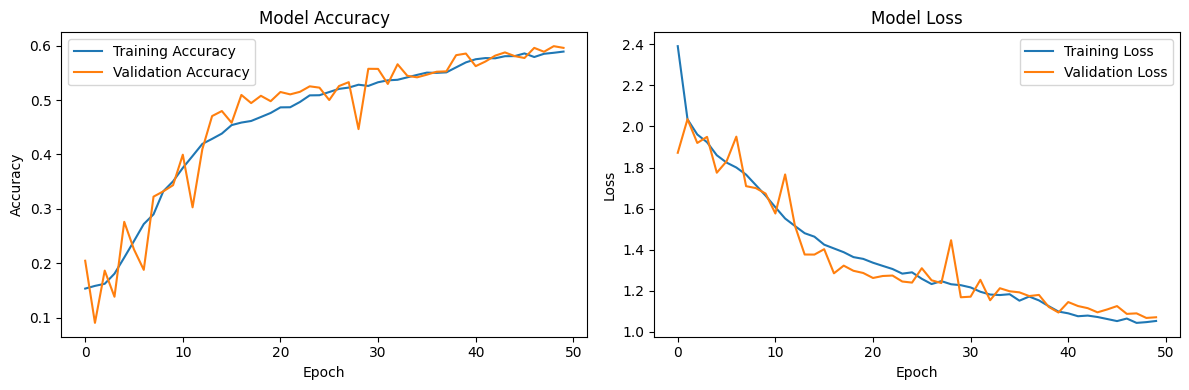

In [18]:
# Load the best saved model
from tensorflow.keras.models import load_model

best_model = load_model('best_emotion_model.h5')

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Save the model in modern Keras format (to avoid warnings)
best_model.save('emotion_detection_model.keras')
print("Model saved as emotion_detection_model.keras")

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()